# EDA — Vehicle Sales Price Prediction

**Team 1** | E2E ML Course 2026  
Dataset: [Vehicle Sales Data](https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data)  
Target variable: `sellingprice` (regression task)

In [18]:
!curl -L "https://docs.google.com/uc?export=download&id=19TRiv2giWEpBpHL3fXrq__5-6VO_5WK7" -o ../data/sample_1.csv 

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 7368k  100 7368k    0     0  3326k      0  0:00:02  0:00:02 --:--:-- 9544k


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

df = raw_df = pd.read_csv('../data/car_prices_sample.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 15)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice,saledate
0,2014,Kia,Optima,LX,Sedan,automatic,5xxgm4a71eg328703,tx,49.0,11485.0,gray,gray,kia motors america inc,15700,Wed Feb 04 2015 02:30:00 GMT-0800 (PST)
1,2014,Kia,Optima,LX,Sedan,automatic,5xxgm4a71eg318141,tx,26.0,14265.0,white,beige,kia motors america inc,15900,Wed Feb 04 2015 02:30:00 GMT-0800 (PST)
2,2006,Chrysler,Town and Country,Limited,Minivan,automatic,2a8gp64l96r821834,az,19.0,92649.0,gold,tan,onesource/southwest remarketing,4700,Thu Jan 22 2015 03:00:00 GMT-0800 (PST)
3,2006,Chevrolet,Silverado 1500,LS,Extended Cab,NaN,1gcek19bx6z269153,tx,22.0,166999.0,white,gray,texas direct auto,6700,Wed Feb 25 2015 02:20:00 GMT-0800 (PST)
4,2013,Chevrolet,Black Diamond Avalanche,LT,Crew Cab,automatic,3gntkfe78dg263779,tn,43.0,29265.0,—,black,north lily auto sales llc,32250,Wed Jan 28 2015 02:30:00 GMT-0800 (PST)


## 1. Basic Dataset Overview

In [20]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          50000 non-null  int64  
 1   make          49090 non-null  object 
 2   model         49084 non-null  object 
 3   trim          49064 non-null  object 
 4   body          48843 non-null  object 
 5   transmission  44134 non-null  object 
 6   vin           49999 non-null  object 
 7   state         50000 non-null  object 
 8   condition     48969 non-null  float64
 9   odometer      49993 non-null  float64
 10  color         49928 non-null  object 
 11  interior      49928 non-null  object 
 12  seller        50000 non-null  object 
 13  sellingprice  50000 non-null  int64  
 14  saledate      50000 non-null  object 
dtypes: float64(2), int64(2), object(11)
memory usage: 5.7+ MB


In [21]:
print("=== Descriptive Statistics (Numerical) ===")
df.describe().round(2)

=== Descriptive Statistics (Numerical) ===


,year,condition,odometer,sellingprice
count,50000.00,48969.00,49993.00,50000.00
mean,2010.07,30.68,68236.45,13654.76
std,3.94,13.44,53220.36,9764.87
min,1985.00,1.00,1.00,100.00
25%,2008.00,23.00,28415.00,7000.00
50%,2012.00,35.00,52363.00,12200.00
75%,2013.00,41.00,98766.00,18200.00
max,2015.00,49.00,999999.00,165000.00


In [22]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'missing_%': missing_pct})[missing > 0]

=== Missing Values ===


,missing,missing_%
make,910,1.82
model,916,1.83
trim,936,1.87
body,1157,2.31
transmission,5866,11.73
vin,1,0.00
condition,1031,2.06
odometer,7,0.01
color,72,0.14
interior,72,0.14


## 2. Target Variable — `sellingprice`

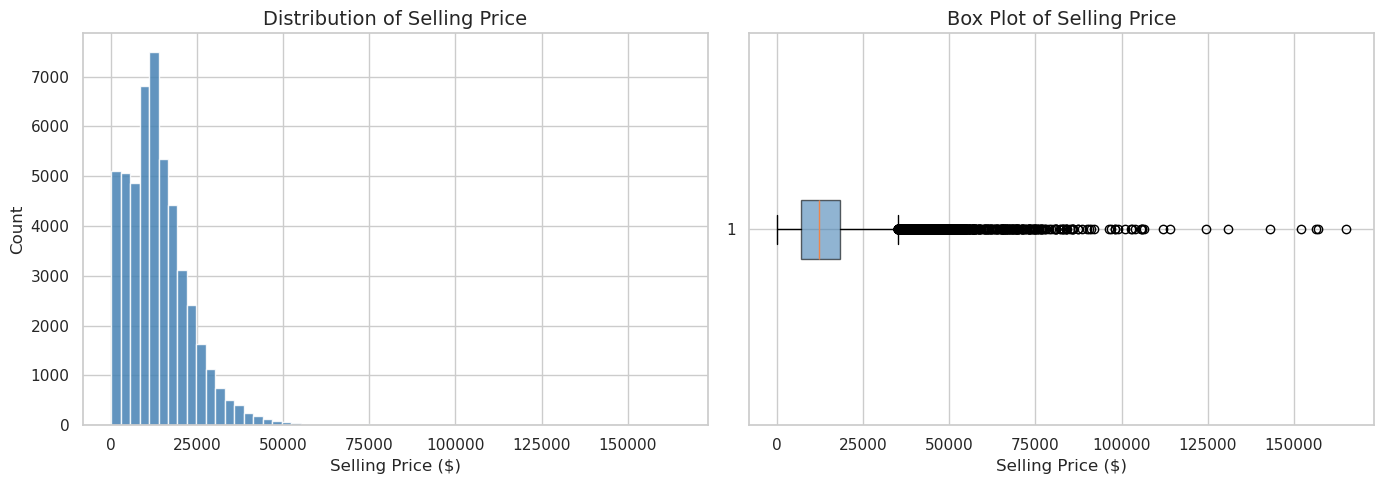

Skewness: 2.000
Kurtosis: 11.582


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['sellingprice'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Selling Price', fontsize=14)
axes[0].set_xlabel('Selling Price ($)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['sellingprice'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot of Selling Price', fontsize=14)
axes[1].set_xlabel('Selling Price ($)')

plt.tight_layout()
#plt.savefig('reports/target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Skewness: {df['sellingprice'].skew():.3f}")
print(f"Kurtosis: {df['sellingprice'].kurt():.3f}")

**Interpretation:** The selling price distribution is right-skewed (long tail at higher prices), which is common for used car markets. Most cars are priced between \$7,000 and \$18,000.

## 3. Numerical Features Analysis

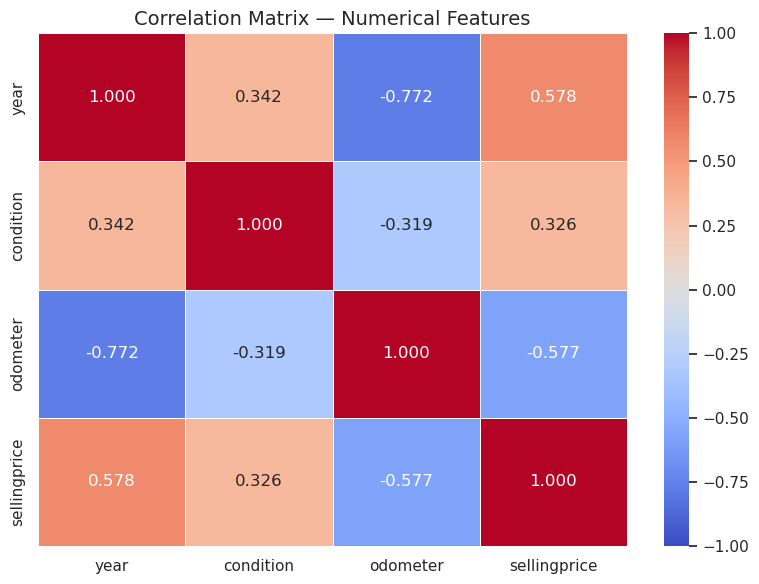

In [24]:
num_cols = ['year', 'condition', 'odometer', 'sellingprice']
df_num = df[num_cols].dropna()

corr = df_num.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14)
plt.tight_layout()
#plt.savefig('reports/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:**
- `year` has a **positive** correlation with `sellingprice` (~0.48): newer cars cost more.
- `odometer` has a **negative** correlation (~−0.50): higher mileage → lower price.
- `condition` has a **positive** correlation (~0.40): better condition → higher price.

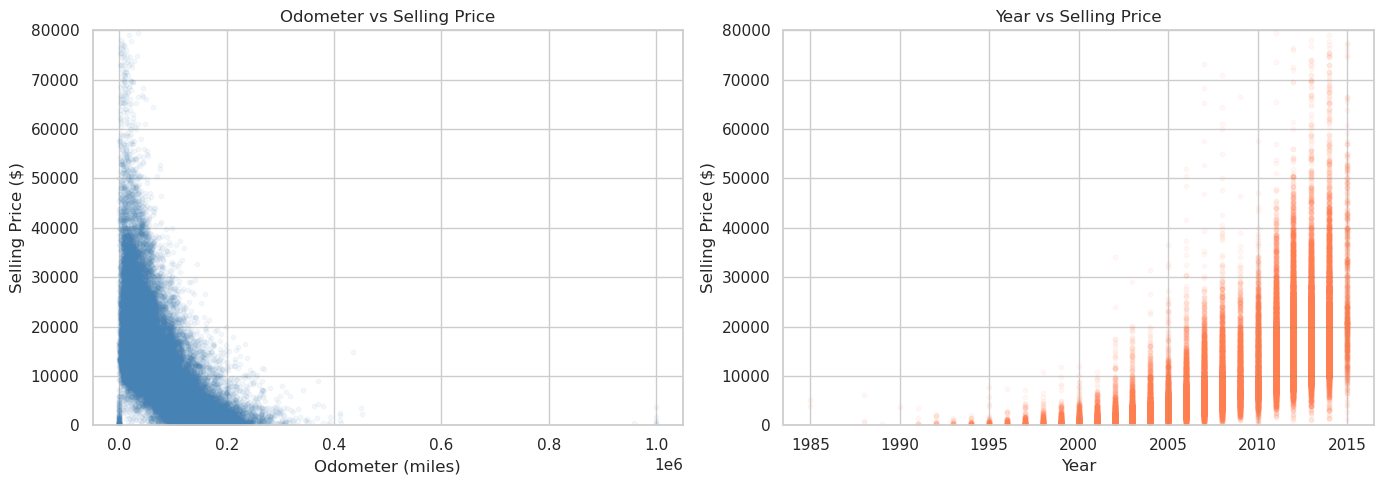

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['odometer'], df['sellingprice'], alpha=0.05, color='steelblue', s=10)
axes[0].set_xlabel('Odometer (miles)')
axes[0].set_ylabel('Selling Price ($)')
axes[0].set_title('Odometer vs Selling Price')
axes[0].set_ylim(0, 80000)

axes[1].scatter(df['year'], df['sellingprice'], alpha=0.05, color='coral', s=10)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Selling Price ($)')
axes[1].set_title('Year vs Selling Price')
axes[1].set_ylim(0, 80000)

plt.tight_layout()
#plt.savefig('reports/scatter_plots.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Categorical Features Analysis

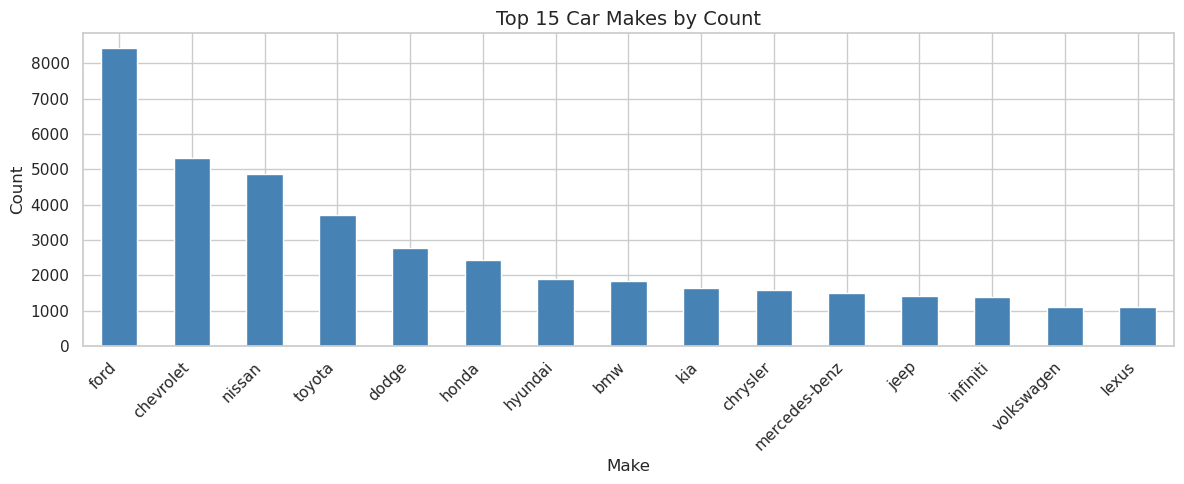

In [26]:
# Standardize case for analysis
df_eda = df.copy()
for col in ['make', 'body', 'transmission', 'state', 'color', 'interior']:
    df_eda[col] = df_eda[col].str.lower().str.strip()

# Make column
top_makes = df_eda['make'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 5))
top_makes.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Car Makes by Count', fontsize=14)
ax.set_xlabel('Make')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig('reports/top_makes.png', dpi=120, bbox_inches='tight')
plt.show()

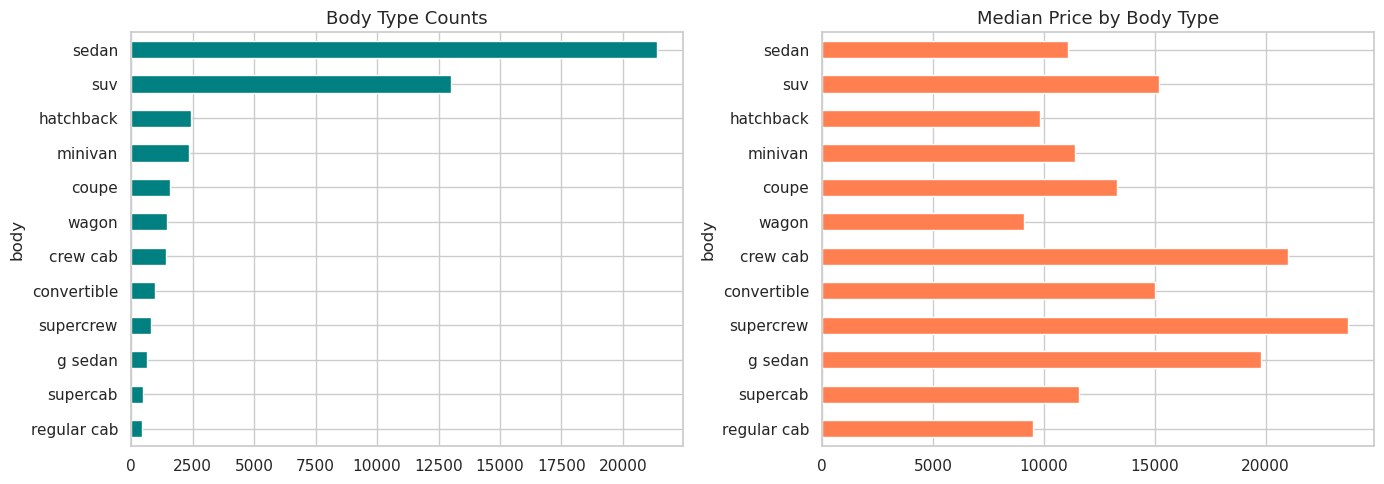

In [27]:
# Body type distribution
body_counts = df_eda['body'].value_counts().head(12)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

body_counts.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Body Type Counts', fontsize=13)
axes[0].invert_yaxis()

order = body_counts.index.tolist()
df_plot = df_eda[df_eda['body'].isin(order)]
df_plot.groupby('body')['sellingprice'].median().reindex(order).plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Median Price by Body Type', fontsize=13)
axes[1].invert_yaxis()

plt.tight_layout()
#plt.savefig('reports/body_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

Transmission counts:
transmission
automatic    42630
manual        1501
sedan            3
Name: count, dtype: int64


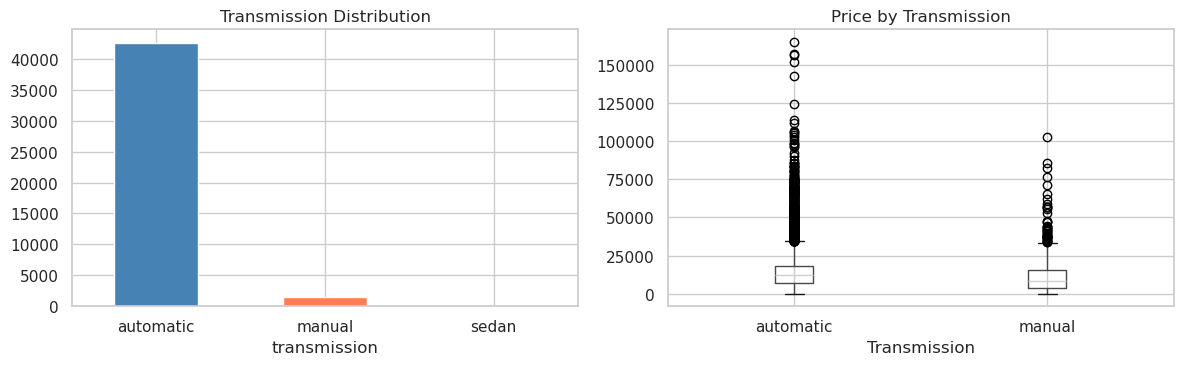

In [28]:
# Transmission
trans = df_eda['transmission'].value_counts()
print("Transmission counts:")
print(trans)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
trans.plot(kind='bar', ax=axes[0], color=['steelblue','coral','gray'])
axes[0].set_title('Transmission Distribution')
axes[0].tick_params(axis='x', rotation=0)

df_eda[df_eda['transmission'].isin(['automatic','manual'])].boxplot(
    column='sellingprice', by='transmission', ax=axes[1])
axes[1].set_title('Price by Transmission')
axes[1].set_xlabel('Transmission')
plt.suptitle('')
plt.tight_layout()
#plt.savefig('reports/transmission_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Year Analysis

Cars before 2005: 5446 (10.9%)


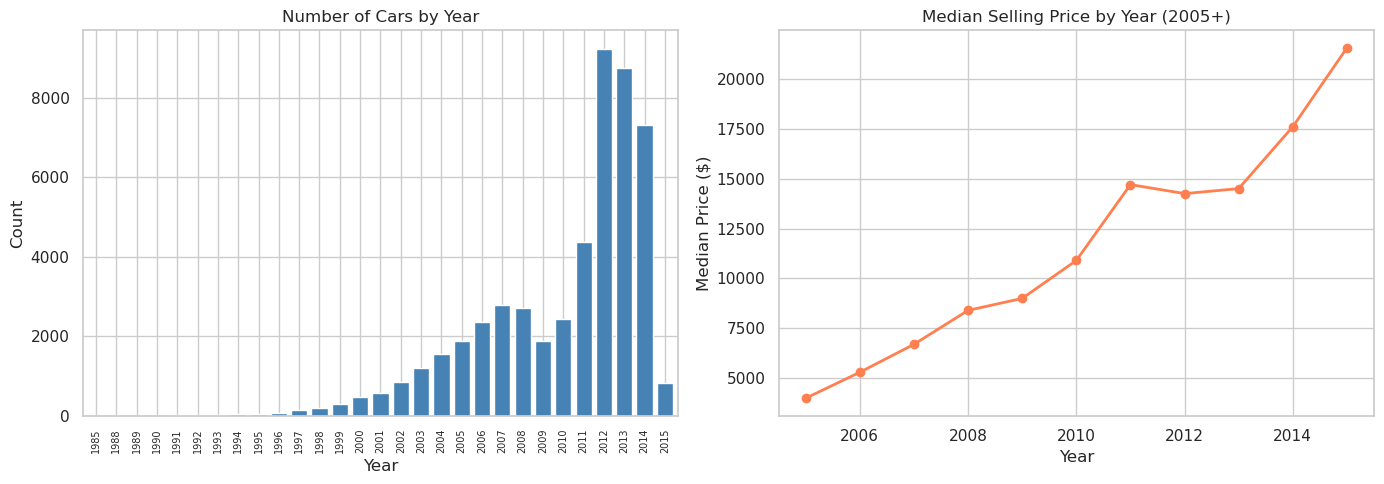

In [29]:
print(f"Cars before 2005: {(df['year'] < 2005).sum()} ({(df['year'] < 2005).mean()*100:.1f}%)")

# Year distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', width=0.8)
axes[0].set_title('Number of Cars by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=90, fontsize=7)

df[df['year'] >= 2005].groupby('year')['sellingprice'].median().plot(
    ax=axes[1], color='coral', marker='o', linewidth=2)
axes[1].set_title('Median Selling Price by Year (2005+)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Price ($)')

plt.tight_layout()
#plt.savefig('reports/year_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Outlier Analysis

Price outliers: 1476 (3.0%)
Lower bound: $-9,800, Upper bound: $35,000


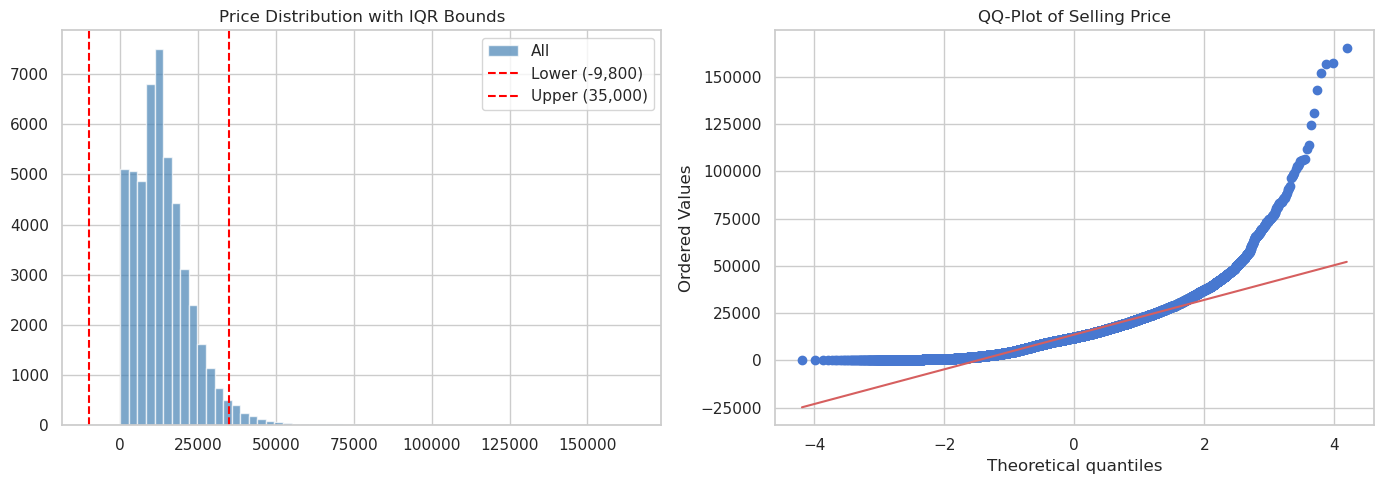

In [30]:
# Price outlier analysis using IQR
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['sellingprice'] < lower) | (df['sellingprice'] > upper)]
print(f"Price outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Lower bound: ${lower:,.0f}, Upper bound: ${upper:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['sellingprice'], bins=60, color='steelblue', alpha=0.7, label='All')
axes[0].axvline(lower, color='red', linestyle='--', label=f'Lower ({lower:,.0f})')
axes[0].axvline(upper, color='red', linestyle='--', label=f'Upper ({upper:,.0f})')
axes[0].set_title('Price Distribution with IQR Bounds')
axes[0].legend()

stats.probplot(df['sellingprice'].dropna(), dist="norm", plot=axes[1])
axes[1].set_title('QQ-Plot of Selling Price')

plt.tight_layout()
#plt.savefig('reports/outlier_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

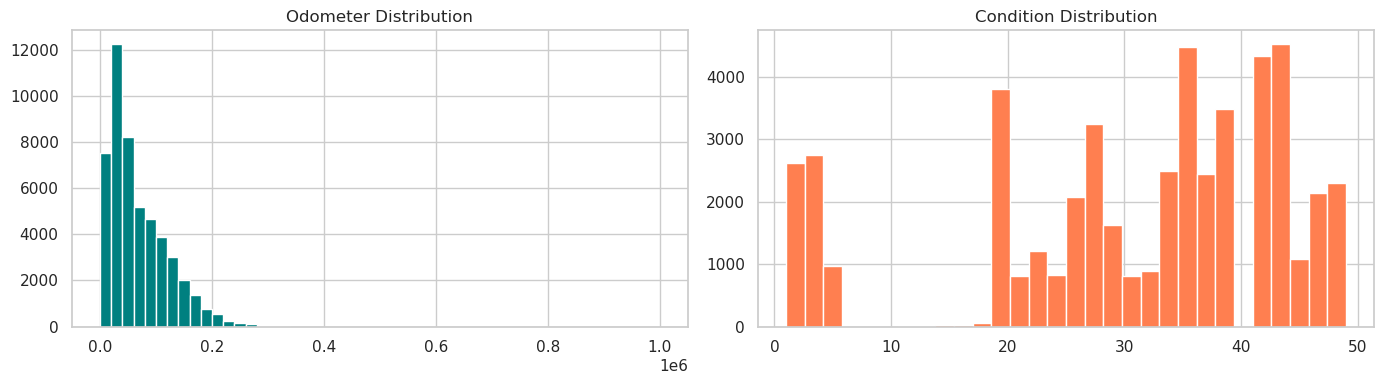

In [31]:
# Odometer outlier check
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['odometer'].hist(bins=50, ax=axes[0], color='teal')
axes[0].set_title('Odometer Distribution')
df['condition'].hist(bins=30, ax=axes[1], color='coral')
axes[1].set_title('Condition Distribution')
plt.tight_layout()
#plt.savefig('reports/other_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Missing Values Imputation

In [32]:
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df_clean = df.copy()

# Impute numerical columns with median
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
df_clean[['condition', 'odometer']] = num_imputer.fit_transform(df_clean[['condition', 'odometer']])

# Impute categorical columns with mode ('most_frequent')
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols_missing = ['make', 'model', 'trim', 'body', 'transmission', 'color', 'interior']
df_clean[cat_cols_missing] = cat_imputer.fit_transform(df_clean[cat_cols_missing])

# Drop rows with missing vin (only 1 row)
df_clean = df_clean.dropna(subset=['vin'])

print("\nMissing values after imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print(f"\nFinal shape: {df_clean.shape}")

Missing values before imputation:
make             910
model            916
trim             936
body            1157
transmission    5866
vin                1
condition       1031
odometer           7
color             72
interior          72
dtype: int64

Missing values after imputation:
Series([], dtype: int64)

Final shape: (49999, 15)


## 8. Feature Importance Analysis

### Key findings from EDA:

**Most important features for `sellingprice` prediction:**

1. **`year`** (correlation ≈ +0.48) — Year of manufacture is one of the strongest predictors. Newer cars consistently sell for more due to lower wear and modern features.

2. **`odometer`** (correlation ≈ −0.50) — Mileage has the strongest single-feature negative correlation. The more miles a car has been driven, the lower its market value.

3. **`condition`** (scale 1–49, correlation ≈ +0.40) — Vehicle condition is a direct proxy for wear and desirability.

4. **`make`** (categorical) — Brand matters enormously: luxury brands (BMW, Mercedes) command premium prices over economy brands. High cardinality (~40 unique values after cleaning).

5. **`body`** (categorical) — Body type (SUV, Sedan, Truck, Coupe) strongly influences price. SUVs and trucks typically sell higher than basic sedans.

6. **`model`** (categorical) — Within a make, model determines the price tier. Very high cardinality (~900+ unique values), requires special encoding (hashing).

**Features that are hard to understand / process:**

- **`vin`** (Vehicle Identification Number) — Contains encoded info (year, plant, sequence), but extracting it requires domain knowledge. Too high cardinality to encode directly → **drop**.
- **`trim`** (e.g., "LX", "EX-L", "Limited") — High cardinality (~2000+ values) and brand-specific meaning. Hard to generalize → **drop or hash-encode**.
- **`saledate`** — Timestamp string; could extract year/month/weekday as features, but this is meta-information about the auction → **drop** (avoid data leakage with target).
- **`seller`** — Company/dealer names; very high cardinality, noisy → **drop**.
- **`state`** — 50 US states; region affects price (taxes, demand). Can be one-hot encoded but adds ~50 columns → **one-hot with grouping** of rare states.
- **`color` / `interior`** — Subjective features. Some colors (white, black) are more popular and resell better. One-hot encode.
- **`transmission`** — 3 values but includes an erroneous 'sedan' entry that must be cleaned. Label encode after cleaning.

In [33]:
print("EDA Summary:")
print(f"Total samples: {df_clean.shape[0]}")
print(f"Total features: {df_clean.shape[1]}")
print(f"Target range: ${df_clean['sellingprice'].min()} - ${df_clean['sellingprice'].max()}")
print(f"Mean price: ${df_clean['sellingprice'].mean():,.0f}")
print(f"Median price: ${df_clean['sellingprice'].median():,.0f}")


EDA Summary:
Total samples: 49999
Total features: 15
Target range: $100 - $165000
Mean price: $13,655
Median price: $12,200
